In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
#| output: false
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-cpu==2.21.0 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow-cpu==2.21.0


# 🔎 Étape 4 : Analyse Exploratoire des Données (EDA)

Explorer les propriétés statistiques du dataset et construire les features qui alimenteront le modèle unifié.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc

print("Librairies importées pour l'EDA !")

Librairies importées pour l'EDA !


### 2. Chargement des données nettoyées

In [3]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
df['duration_min'] = df['duration_ms'] / 60000
df['is_popular'] = (df['popularity'] >= 50).astype(int)

print(f"Dataset chargé : {df.shape}")
#| output: false
df.head()

Dataset chargé : (114000, 26)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,liveness,valence,tempo,time_signature,track_genre,genre_family,genre_family_name,is_hit,duration_min,is_popular
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0.3580,0.715,87.917,4,acoustic,2,Acoustique / Singer-Songwriter,1,3.844433,1
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,0.1010,0.267,77.489,4,acoustic,2,Acoustique / Singer-Songwriter,1,2.493500,1
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,0.1170,0.120,76.332,4,acoustic,2,Acoustique / Singer-Songwriter,1,3.513767,1
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,0.1320,0.143,181.740,3,acoustic,2,Acoustique / Singer-Songwriter,1,3.365550,1
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,0.0829,0.167,119.949,4,acoustic,2,Acoustique / Singer-Songwriter,1,3.314217,1


### 3. Statistiques Descriptives

97 270 morceaux après nettoyage. Popularité moyenne 38.7 (std=19.2), dansabilité 0.57 — distribution large, bonne variance pour l'entraînement. Seulement 8.6% de contenu explicite.

In [4]:
#  Résumé statistique global
print("=== Statistiques globales ===")
#| output: false
df.describe()

=== Statistiques globales ===


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_family,is_hit,duration_min,is_popular
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,1.719298,0.257605,3.800486,0.257605
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,1.614138,0.437317,1.788295,0.437317
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,0.000000,0.000000,2.901100,0.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,2.000000,0.000000,3.548433,0.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,4.000000,1.000000,4.358433,1.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,4.000000,1.000000,87.288250,1.000000


In [5]:
#  Proportion de chansons explicites
print("=== Chansons explicites ===")
explicite = df['explicit'].value_counts(normalize=True) * 100
print(f"Explicites     : {explicite[True]:.1f}%")
print(f"Non explicites : {explicite[False]:.1f}%")

=== Chansons explicites ===
Explicites     : 8.6%
Non explicites : 91.5%


In [6]:
#  Statistiques par genre musical
print("=== Moyenne par genre ===")
#| output: false

df.groupby('track_genre')[['popularity', 'danceability', 'energy', 'tempo']].mean().round(2)



=== Moyenne par genre ===


,popularity,danceability,energy,tempo
track_genre,,,,
acoustic,42.48,0.55,0.44,119.01
afrobeat,24.40,0.67,0.70,119.21
alt-rock,33.94,0.53,0.75,124.63
alternative,24.34,0.56,0.72,122.23
ambient,44.19,0.37,0.24,111.11
...,...,...,...,...
techno,39.04,0.68,0.75,128.26
trance,37.64,0.58,0.85,133.28
trip-hop,34.46,0.63,0.62,118.74


In [7]:
#  Top 10 des artistes les plus populaires
print("=== Top 10 artistes ===")
#| output: false

df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)

=== Top 10 artistes ===


artists
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Rema;Selena Gomez               92.0
Harry Styles                    92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: popularity, dtype: float64

### 4. Feature Engineering

Les 9 features audio Spotify corrèlent faiblement avec la popularité brute (r < 0.07). On construit donc les **3 variables clés du modèle unifié** :

| Feature | Construction | Rôle |
|---|---|---|
| `artist_reputation` | Popularité moyenne de l'artiste sur tout son catalogue | Capture le poids de la notoriété |
| `pop_rank_in_genre` | Rang percentile dans le genre (0=pire, 1=meilleur) | **Cible du modèle** — compare à la vraie concurrence |
| `dance_energy_score` | danceability × energy | Combinaison audio testée comme prédicteur |

In [8]:
df_feat = df.copy()

# Features audio classiques
df_feat['duration_min']          = df_feat['duration_ms'] / 60000
df_feat['explicit_int']          = df_feat['explicit'].astype(int)
df_feat['dance_energy_score']    = df_feat['danceability'] * df_feat['energy']
df_feat['energy_acoustic_ratio'] = df_feat['energy'] / (df_feat['acousticness'] + 0.001)

# Variable contexte (ancienne approche)
df_feat['is_popular'] = (df_feat['popularity'] >= 50).astype(int)

# === NOUVELLES FEATURES DU MODÈLE UNIFIÉ ===
# Réputation artiste : popularité moyenne de l'artiste dans le dataset
df_feat['artist_reputation'] = df_feat.groupby('artists')['popularity'].transform('mean')

# Cible du modèle : rang percentile dans le genre (0=pire, 1=meilleur)
df_feat['pop_rank_in_genre'] = df_feat.groupby('track_genre')['popularity'].transform(
    lambda x: x.rank(pct=True)
)

print("Features créées :")
print(f"  artist_reputation : mean={df_feat['artist_reputation'].mean():.1f}, max={df_feat['artist_reputation'].max():.1f}")
print(f"  pop_rank_in_genre : mean={df_feat['pop_rank_in_genre'].mean():.3f} (distribution uniforme dans chaque genre)")
df_feat[['track_name','artists','popularity','artist_reputation','pop_rank_in_genre']].head()

Features créées :
  artist_reputation : mean=33.2, max=100.0
  pop_rank_in_genre : mean=0.500 (distribution uniforme dans chaque genre)


,track_name,artists,popularity,artist_reputation,pop_rank_in_genre
0,Comedy,Gen Hoshino,73,58.000000,0.9915
1,Ghost - Acoustic,Ben Woodward,55,42.923077,0.7730
2,To Begin Again,Ingrid Michaelson;ZAYN,57,57.000000,0.8350
3,Can't Help Falling In Love,Kina Grannis,71,53.933333,0.9880
4,Hold On,Chord Overstreet,82,41.727273,1.0000


### 5. Corrélations — Popularité brute vs Rang relatif

Deux analyses de corrélation : sur la popularité brute (ce qui ne marche pas) puis sur `pop_rank_in_genre` (la vraie cible). `artist_reputation` est le seul signal fort.

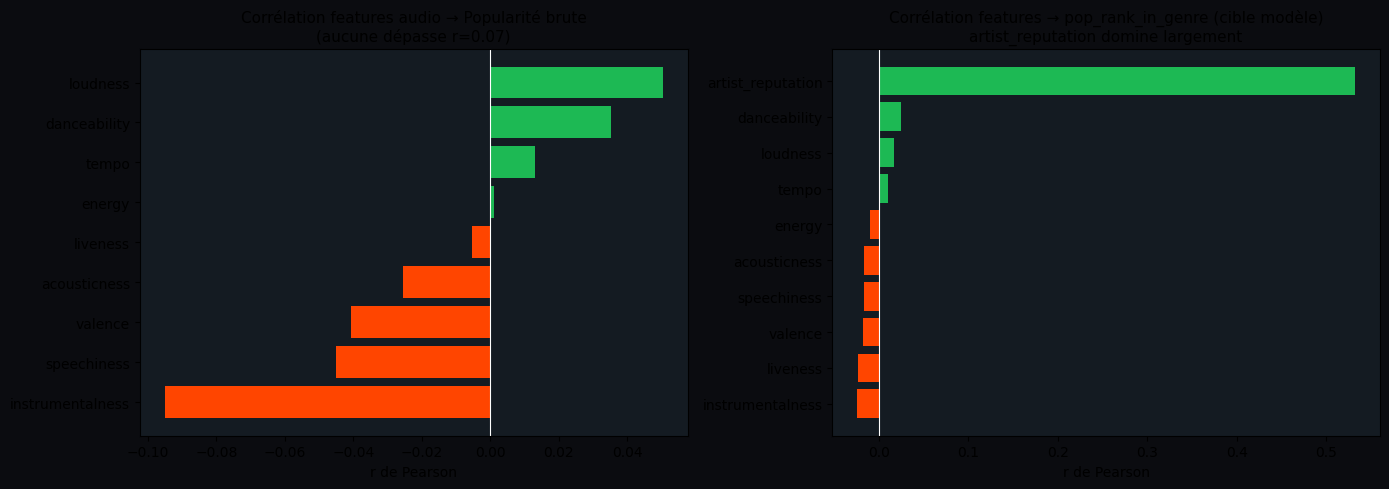


=== Signal de artist_reputation ===
Corrélation avec popularité brute    : 0.856
Corrélation avec pop_rank_in_genre   : 0.532


In [9]:
audio_cols = ['danceability','energy','loudness','speechiness',
              'acousticness','instrumentalness','liveness','valence','tempo']

# --- Corrélations avec la popularité BRUTE ---
corr_raw  = df_feat[audio_cols].corrwith(df_feat['popularity']).sort_values()

# --- Corrélations avec pop_rank_in_genre (la vraie cible) ---
corr_rank = df_feat[audio_cols + ['artist_reputation']].corrwith(df_feat['pop_rank_in_genre']).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(corr_raw.index, corr_raw.values, color=['#ff4500' if v < 0 else '#1DB954' for v in corr_raw])
axes[0].axvline(0, color='white', lw=0.8)
axes[0].set_title("Corrélation features audio → Popularité brute\n(aucune dépasse r=0.07)", fontsize=11)
axes[0].set_xlabel("r de Pearson")

colors_rank = ['#ff4500' if v < 0 else '#1DB954' for v in corr_rank.values]
axes[1].barh(corr_rank.index, corr_rank.values, color=colors_rank)
axes[1].axvline(0, color='white', lw=0.8)
axes[1].set_title("Corrélation features → pop_rank_in_genre (cible modèle)\nartist_reputation domine largement", fontsize=11)
axes[1].set_xlabel("r de Pearson")

for ax in axes:
    ax.set_facecolor('#141b22')
    ax.figure.set_facecolor('#0b0c10')

plt.tight_layout()
plt.show()

print("\n=== Signal de artist_reputation ===")
print(f"Corrélation avec popularité brute    : {df_feat['artist_reputation'].corr(df_feat['popularity']):.3f}")
print(f"Corrélation avec pop_rank_in_genre   : {df_feat['artist_reputation'].corr(df_feat['pop_rank_in_genre']):.3f}")